### SQL 데이터베이스와 상호작용하는 에이전트

이 튜토리얼에서는 **SQL 데이터베이스에 대한 질문에 답할 수 있는 에이전트**를 단계별로 구축하는 방법을 소개합니다.  

SQL 쿼리를 실행하는 에이전트의 흐름은 다음과 같습니다.

1. **데이터베이스 스키마 파악**: 사용 가능한 테이블 목록을 가져옵니다.
2. **관련 테이블 선택**: 질문과 연관된 테이블을 선택합니다.
3. **DDL 조회**: 선택된 테이블의 스키마 정의(DDL)를 가져옵니다.
4. **쿼리 생성**: 질문과 DDL 정보에 기반하여 SQL 쿼리를 작성합니다.
5. **쿼리 점검**: LLM을 사용하여 일반적인 오류를 검토하고 쿼리를 개선합니다.
6. **쿼리 실행 및 오류 처리**: 데이터베이스 엔진에 쿼리를 실행하고, 오류 발생 시 수정하여 성공적으로 쿼리를 수행합니다.
7. **응답 생성**: 쿼리 결과를 기반으로 최종 답변을 제공합니다.

![](./assets/langgraph-sql-agent.png)

---

**주요 내용**

- **데이터베이스**: SQLite 데이터베이스 설정 및 `chinook` 샘플 데이터베이스 로드  
- **유틸리티 함수**: 에이전트 구현을 위한 유틸리티 함수 정의  
- **도구 정의**: 데이터베이스와 상호작용하기 위한 도구 정의  
- **워크플로우 정의**: 에이전트의 워크플로우(그래프) 정의  
- **그래프 시각화**: 정의된 그래프 시각화  
- **에이전트 실행**: 에이전트 실행 및 결과 확인  
- **평가**: 에이전트 평가 및 성능 비교  

LangSmith 추적을 시작합니다.
[프로젝트명]
SQL Agent Graph


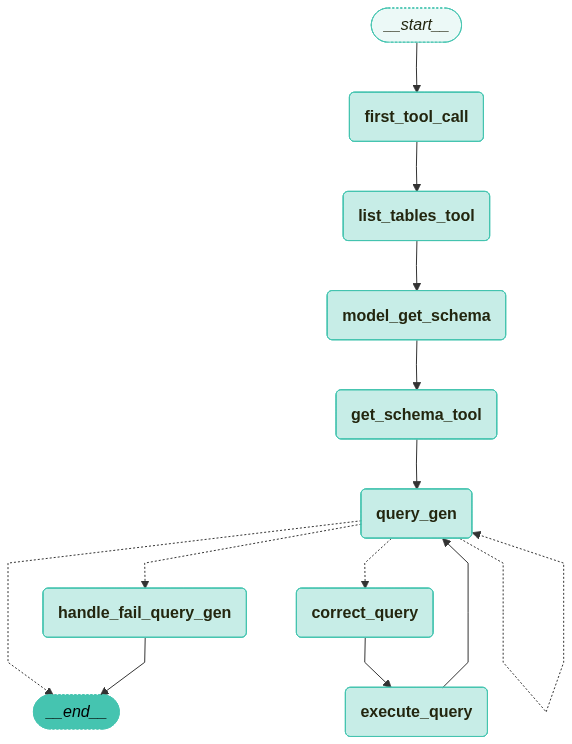

In [2]:
from feature.use_cases.SQLAgentGraph import SQLAgentGraph
from util.postgres_connection import connect_postgres

workflow = SQLAgentGraph(connect_postgres(load_env=False), langsmith_project="SQL Agent Graph")
workflow.show_graph()

In [5]:
from langchain_core.messages import HumanMessage
from langgraph.graph.state import RunnableConfig

from util.messages import random_uuid


_ = workflow.invoke(
    inputs={
        "messages": [HumanMessage(content="hashtag 테이블에 jyuka가 작성한 데이터 조회")]
    },
    config=RunnableConfig(configurable={"thread_id": '1234'})
)


🔄 Node: first_tool_call 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (initial_tool_call_06923223-b116-4ffa-a5b3-b4e076af6ced)
 Call ID: initial_tool_call_06923223-b116-4ffa-a5b3-b4e076af6ced
  Args:

🔄 Node: list_tables_tool 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: sql_db_list_tables

admin_account, distribution, email_code, emp_wait, emp_wait_list, hashtag, hashtag_articles, member, oauth2user_account, party, party_member, refresh_token, role_type, runtime_demo_notes, sales_history, user_account

🔄 Node: model_get_schema 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_FB1rjKUNKqz8tgau1asD5HKm)
 Call ID: call_FB1rjKUNKqz8tgau1asD5HKm
  Args:
    tabl

## LangSmith Evaluator를 활용한 SQL Agent 평가

이제 생성한 Agent의 SQL 쿼리 응답을 평가합니다. 에이전트 평가는 단순히 코드가 실행되는지 확인하는 것이 아니라, 실제 질문에 대해 올바른 답변을 생성하는지 체계적으로 검증하는 중요한 과정입니다. LangSmith를 활용하면 평가 결과를 시각화하고 관리하며, 모델 또는 프롬프트 변경 시 성능 변화를 쉽게 비교·분석할 수 있습니다.

평가를 위해 다음 단계를 수행합니다:

1. **평가용 데이터셋 생성**: 질문과 정답 쌍으로 구성된 데이터셋을 LangSmith에 업로드
2. **예측 함수 정의**: 에이전트의 응답을 예측하는 함수 정의
3. **평가자 정의**: LLM-as-judge 방식의 평가자 정의
4. **평가 실행**: 데이터셋에 대해 평가를 수행하고 결과 확인

평가용 데이터셋은 `(질문, 정답)` 형태의 예제 쌍으로 구성됩니다. 데이터셋이 이미 LangSmith에 존재하는 경우에는 새로 생성하지 않고 기존 데이터셋을 재사용하여 실험의 일관성을 유지합니다. 아래 코드는 5개의 테스트 예제를 포함하는 데이터셋을 생성하고 LangSmith에 업로드합니다.

In [19]:
from langsmith import Client

# 클라이언트 초기화
client = Client()

# 데이터셋 생성 및 업로드
examples = [
    (
        "Which country's customers spent the most? And how much did they spend?",
        "The country whose customers spent the most is the USA, with a total spending of 523.06.",
    ),
    (
        "What was the most purchased track of 2013?",
        "The most purchased track of 2013 was Hot Girl.",
    ),
    (
        "How many albums does the artist Led Zeppelin have?",
        "Led Zeppelin has 14 albums",
    ),
    (
        "What is the total price for the album “Big Ones”?",
        "The total price for the album 'Big Ones' is 14.85",
    ),
    (
        "Which sales agent made the most in sales in 2009?",
        "Steve Johnson made the most sales in 2009",
    ),
]

dataset_name = "SQL Agent Response"

if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name)
    inputs, outputs = zip(
        *[({"input": text}, {"output": label}) for text, label in examples]
    )
    client.create_examples(inputs=inputs, outputs=outputs, dataset_id=dataset.id)

다음으로는 에이전트의 SQL 쿼리 응답을 예측하기 위한 함수를 정의합니다. 이 함수는 입력 질문을 받아 에이전트를 실행하고 최종 응답을 반환합니다.

In [20]:
# 에이전트의 SQL 쿼리 응답을 예측하기 위한 함수 정의
def predict_sql_agent_answer(example: dict):
    """평가를 위한 SQL 에이전트 응답 예측 함수입니다.

    입력 질문을 에이전트에 전달하고 최종 응답을 추출하여 반환합니다.
    SubmitFinalAnswer 도구 호출 시 final_answer 필드에서 답변을 추출합니다.
    """
    config = RunnableConfig(configurable={"thread_id": random_uuid()})

    inputs = {
        "messages": [HumanMessage(content=example["input"])],
    }
    # 그래프를 실행하여 메시지 결과 조회
    messages = app.invoke(inputs, config)
    last_message = messages["messages"][-1]

    # SubmitFinalAnswer 도구 호출 시 final_answer 필드에서 답변 추출
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        for tc in last_message.tool_calls:
            if tc["name"] == "SubmitFinalAnswer":
                return {"response": tc["args"].get("final_answer", "")}

    # 텍스트 형태로 답변이 반환된 경우
    return {"response": last_message.content}

SQL 쿼리 응답을 평가하기 위한 프롬프트와 평가자(LLM-as-judge)를 정의합니다. LLM-as-judge 방식은 LLM이 생성한 응답을 또 다른 LLM이 평가하는 방식으로, 자연어로 표현된 답변의 정확성을 자동으로 측정하는 데 효과적입니다. 고정된 규칙으로 평가하기 어려운 자유 형식의 텍스트 응답을 처리할 때 특히 유용하며, `langchain-ai/rag-answer-vs-reference` 허브 프롬프트와 동일한 기준으로 직접 프롬프트를 정의합니다.

`with_structured_output()`은 LLM의 응답을 Pydantic 모델과 같은 구조화된 형식으로 안정적으로 추출할 수 있게 해주는 기능입니다. 일반 텍스트 파싱 대신 구조화된 출력을 사용하면 점수 추출 과정에서 발생할 수 있는 파싱 오류를 최소화하고, 일관된 형식의 결과를 얻을 수 있습니다. 평가자는 예측 답변과 참조 답변을 비교하여 정확도 점수(0 또는 1)를 반환합니다.

> 📖 **참고 문서**: [with_structured_output](https://python.langchain.com/docs/concepts/structured_outputs/)

아래 코드는 `GradeAnswer` 스키마와 `answer_evaluator` 함수를 정의합니다.

In [25]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field


# 답변 정확도 평가 점수 스키마 정의
class GradeAnswer(BaseModel):
    """답변의 정확도를 평가하는 점수 스키마"""

    Score: int = Field(description="0 means incorrect, 1 means correct")


# 답변 정확도 평가 프롬프트 정의 (langchain-ai/rag-answer-vs-reference 기준 동일)
grade_prompt_answer_accuracy = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a teacher grading a quiz.

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER.

Here is the grade criteria to follow:
(1) Grade the student answers being not strictly wrong.
(2) Ensure the student answer does not contradict the correct answer.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is not contradictory.

Score: 1 means the student's answer meets all of the criteria. This is the highest (best) score.
Score: 0 means the student's answer does not meet all of the criteria. This is the lowest possible score you can give.""",
        ),
        (
            "human",
            "QUESTION: {question}\n\nGROUND TRUTH ANSWER: {correct_answer}\n\nSTUDENT ANSWER: {student_answer}",
        ),
    ]
)


# 답변 평가자 LLM-as-judge 정의
def answer_evaluator(run, example) -> dict:
    """LLM-as-judge 방식으로 에이전트 응답의 정확도를 평가합니다.

    참조 답변과 예측 답변을 비교하여 정확도 점수(0 또는 1)를 반환합니다.
    """
    # input: 질문
    input_question = example.inputs["input"]
    # output: 참조 답변
    reference = example.outputs["output"]
    # 예측 답변
    prediction = run.outputs["response"]

    # OpenAI 키를 사용하는 경우 gpt-5.2, gpt-4.1-mini 등의 모델로 변경하세요
    # LLM 평가자 초기화 (structured output으로 점수를 안정적으로 추출)
    llm = init_chat_model("claude-sonnet-4-5", temperature=0)
    answer_grader = grade_prompt_answer_accuracy | llm.with_structured_output(
        GradeAnswer
    )

    # 평가자 실행
    score = answer_grader.invoke(
        {
            "question": input_question,
            "correct_answer": reference,
            "student_answer": prediction,
        }
    )

    # 점수 반환
    return {"key": "answer_v_reference_score", "score": score.Score}

이제 LangSmith의 `evaluate()` 함수를 사용하여 실제 평가를 수행합니다. `evaluate()` 함수는 데이터셋의 각 예제를 예측 함수에 전달하고, 반환된 결과를 평가자가 채점하는 전체 파이프라인을 자동으로 실행합니다. 평가가 진행되는 동안 결과는 LangSmith 대시보드에 실시간으로 업로드되어 바로 확인할 수 있습니다.

`num_repetitions` 파라미터를 설정하면 동일한 테스트를 여러 번 반복 실행할 수 있습니다. LLM 응답에는 확률적 특성이 있어 동일한 질문에도 다소 다른 답변이 생성될 수 있으므로, 반복 실행을 통해 평균적인 성능을 측정하는 것이 중요합니다. `experiment_prefix`는 LangSmith에서 실험을 식별하는 이름 접두사로, 여러 실험의 결과를 구분하고 비교 분석할 때 활용됩니다.

아래 코드는 `sql-agent-eval` 실험을 3회 반복 실행하고 평가 결과를 LangSmith에 기록합니다.

In [26]:
from langsmith.evaluation import evaluate

# 평가용 데이터셋 이름
dataset_name = "SQL Agent Response"

try:
    # 평가 진행
    experiment_results = evaluate(
        predict_sql_agent_answer,  # 평가시 활용할 예측 함수
        data=dataset_name,  # 평가용 데이터셋 이름
        evaluators=[answer_evaluator],  # 평가자 목록
        num_repetitions=3,  # 실험 반복 횟수 설정
        experiment_prefix="sql-agent-eval",
        metadata={
            "version": "chinook db, sql-agent-eval: claude-sonnet-4-5"
        },  # 실험 메타데이터
    )
except Exception as e:
    print(e)

View the evaluation results for experiment: 'sql-agent-eval-022152f5' at:
https://smith.langchain.com/o/42ebd69b-2565-441c-b868-9709c2e20267/datasets/3e801af3-038d-445d-887b-379a30a14939/compare?selectedSessions=e048c123-2df9-4af2-ae12-cc8f56ea2246




0it [00:00, ?it/s]

평가 결과는 생성된 URL에서 확인할 수 있습니다. LangSmith 대시보드에서 각 실험의 상세 결과를 분석할 수 있습니다.

![](./assets/langgraph-sql-agent-evaluation.png)